In [13]:
import os
import glob
import pandas as pd
import re
import matplotlib.pyplot as plt

In [14]:
meta = pd.read_excel("data/Tor.com Originals Gender.xlsx")
meta.columns = meta.columns.str.strip()

meta = meta[meta['Type'] == 'Original Fiction']

In [15]:
def normalize_title(t):
    t = str(t).lower().strip()
    t = re.sub(r'[^\w\s]', '', t)  
    t = re.sub(r'\s+', ' ', t)
    return t

meta['title_norm'] = meta['Title'].apply(normalize_title)

In [16]:
rows = []
for fp in glob.glob("data/text/*.txt"):
    with open(fp, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()

    raw_title = os.path.basename(fp).replace(".txt", "")
    clean_title = re.sub(r'^\d+\s*', '', raw_title) 
    word_count = len(text.split())
    rows.append((clean_title, word_count))

words_df = pd.DataFrame(rows, columns=["title_raw", "word_count"])
words_df['title_norm'] = words_df['title_raw'].apply(normalize_title)

In [17]:
meta_titles = set(meta['title_norm'])
file_titles = set(words_df['title_norm'])
print("In files but not metadata:", list(file_titles - meta_titles)[:10])
print("In metadata but not files:", list(meta_titles - file_titles)[:10])

In files but not metadata: ['', 'the black cat', 'join or die', 'schrodingers gun', 'amicae aeternum', 'the man with the knives', 'portrait of the book as golem', 'playing nice with gods bowling ball', 'the fifth dragon', 'the death of araweilo']
In metadata but not files: ['where the lost things are', 'sword spore', 'the trains that climb the winter tree', 'long is the way', 'the city quiet as death', 'the far side of the universe', 'schrödingers gun', 'the station of the twelfth', 'the locked coffin a judge dee mystery', 'i speak fluent giraffe']


In [18]:
compiled_stats = meta.merge(words_df, on='title_norm', how='inner')
print(f"Merged rows: {len(compiled_stats)}")
print(compiled_stats.columns.tolist()) 

Merged rows: 626
['Publication Date', 'Title', 'Author', 'Pronoun', 'Edited by', 'Edited by 2', 'Series', 'Type', 'Category', 'Category.1', 'Category.2', 'Word Count', 'Page Count', 'title_norm', 'title_raw', 'word_count']


In [19]:
title_counts = compiled_stats['Title'].value_counts().rename('author_count')
compiled_stats = compiled_stats.join(title_counts, on='Title')
compiled_stats['adjusted_wc'] = compiled_stats['word_count'] / compiled_stats['author_count']

In [20]:
compiled_stats['Pronoun'] = compiled_stats['Pronoun'].str.lower().str.strip()

compiled_stats['year'] = pd.to_datetime(compiled_stats['Publication Date'], errors='coerce').dt.year

In [21]:
time_series = compiled_stats.groupby(['year', 'Pronoun'])['adjusted_wc'].sum().reset_index()

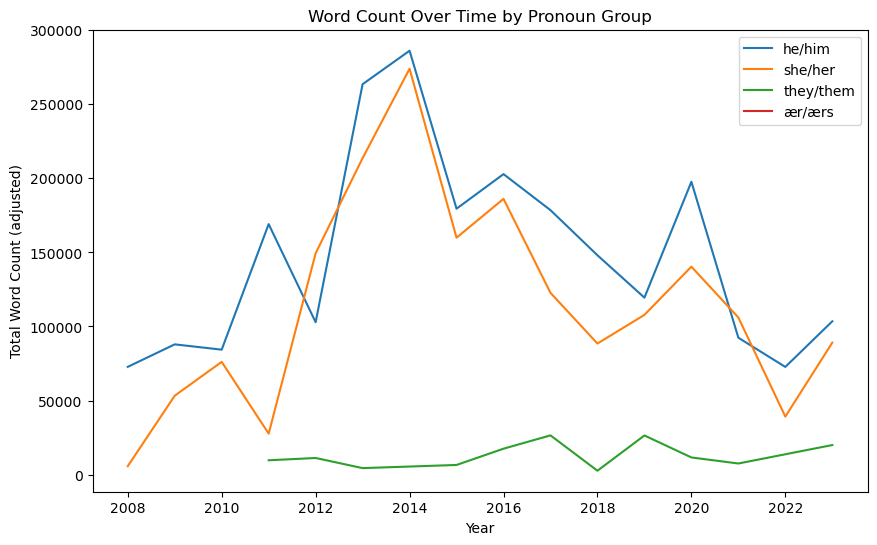

In [22]:
plt.figure(figsize=(10, 6))
for pronoun, grp in time_series.groupby('Pronoun'):
    plt.plot(grp['year'], grp['adjusted_wc'], label=pronoun)

plt.xlabel("Year")
plt.ylabel("Total Word Count (adjusted)")
plt.title("Word Count Over Time by Pronoun Group")
plt.legend()
plt.show() 

In [23]:
print(compiled_stats["Publication Date"].head(10))
print(compiled_stats["Publication Date"].dtype)

0   2008-07-20
1   2008-07-20
2   2008-08-06
3   2008-08-26
4   2008-09-11
5   2008-10-01
6   2008-10-09
7   2008-10-29
8   2008-12-17
9   2009-01-15
Name: Publication Date, dtype: datetime64[ns]
datetime64[ns]
